# Phase 4: Model Training, Evaluation & Registry
**AAI-540 ML Ops - Group 8**   
**Author:** Jagadeesh Kumar Sellappan

## Overview
This notebook trains and evaluates the binary sentiment classifier on the engineered "wide table" produced in Phase 3. We establish a simple benchmark model first to set a minimum performance bar, then train the production candidate model on the same train/validation/test splits, and register the approved model to the SageMaker Model Registry for downstream deployment.

The notebook executes the following sequence:

* **Benchmark Model:** A Logistic Regression classifier trained on the 5 structured features only (no text embeddings), using `class_weight='balanced'` to account for the dataset's 75/25 class imbalance. This establishes the minimum viable performance bar that the production model must clear.
* **Feature Embedding:** Review text is converted into 384-dimensional semantic vectors using `all-MiniLM-L6-v2`, merged with the 5 structured features to form the full 389-feature training matrix (1 label + 5 structured + 384 embeddings).
* **Production Model Training:** An XGBoost classifier is trained via a SageMaker Training Job on the full feature set, with `scale_pos_weight=2.92` to correct for the naturally imbalanced 75/25 class split.
* **Evaluation:** The trained model is scored on the held-out Test split (10%) using macro F1, accuracy, and AUC-ROC, alongside SHAP feature importance analysis to validate that the model's decisions align with the EDA's statistical findings.
* **Model Registry:** The trained model, along with its evaluation metrics, is registered to the SageMaker Model Registry (`cx-cortalyst-sentiment-models`) and marked Approved if it clears the minimum F1 threshold.
* **Batch Transform:** The Approved model is run against the Production Holdout split (40%) to simulate real-world daily inference and generate the baseline predictions used by Model Monitor in Phase 5.

In [1]:
!pip uninstall -y sagemaker sagemaker-core sagemaker-train sagemaker-serve sagemaker-mlops sagemaker-studio

Found existing installation: sagemaker 2.232.2


Uninstalling sagemaker-2.232.2:


  Successfully uninstalled sagemaker-2.232.2


Found existing installation: sagemaker-core 1.0.78
Uninstalling sagemaker-core-1.0.78:
  Successfully uninstalled sagemaker-core-1.0.78


In [2]:
!pip install "sagemaker-core==1.0.78" --quiet

In [3]:
!pip install "sagemaker==2.232.2" --no-deps --quiet

In [4]:
!pip install scikit-learn sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.4/596.4 kB 29.9 MB/s  0:00:00


In [5]:
!pip install tf-keras

  Using cached tf_keras-2.21.0-py3-none-any.whl.metadata (1.8 kB)


  Using cached tensorflow-2.21.0-cp312-cp312-manylinux_2_27_x86_64.whl.metadata (4.4 kB)


  Using cached libclang-18.1.1-py2.py3-none-manylinux2010_x86_64.whl.metadata (5.2 kB)


  Using cached h5py-3.14.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.7 kB)


Using cached tf_keras-2.21.0-py3-none-any.whl (1.7 MB)


...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━ 3/4 [tf-keras]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━ 3/4 [tf-keras]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━ 3/4 [tf-keras]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━ 3/4 [tf-keras]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [tf-keras]


In [6]:
!pip install datasets

In [7]:
pip install --force-reinstall tensorflow

  Using cached tensorflow-2.21.0-cp312-cp312-manylinux_2_27_x86_64.whl.metadata (4.4 kB)


  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)


  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)


  Using cached libclang-18.1.1-py2.py3-none-manylinux2010_x86_64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached packaging-26.2-py3-none-any.whl.metadata (3.5 kB)


  Using cached protobuf-7.35.1-cp310-abi3-manylinux2014_x86_64.whl.metadata (595 bytes)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)


...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━ 30/32 [keras]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━ 30/32 [keras]

  Attempting uninstall: tensorflow
    Found existing installation: tensorflow None
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━ 31/32 [tensorflow]

error: uninstall-no-record-file

× Cannot uninstall tensorflow None
╰─> The package's contents are unknown: no RECORD file was found for tensorflow.

hint: You might be able to recover from this via: pip install --force-reinstall --no-deps tensorflow==2.19.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━ 31/32 [tensorflow]


Note: you may need to restart the kernel to use updated packages.


In [9]:
pip install --force-reinstall --no-deps tensorflow==2.19.1

  Using cached tensorflow-2.19.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.1 kB)
Using cached tensorflow-2.19.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (645.0 MB)


  Attempting uninstall: tensorflow
    Found existing installation: tensorflow None


error: uninstall-no-record-file

× Cannot uninstall tensorflow None
╰─> The package's contents are unknown: no RECORD file was found for tensorflow.

hint: You might be able to recover from this via: pip install --force-reinstall --no-deps tensorflow==2.19.1


Note: you may need to restart the kernel to use updated packages.


In [11]:
!pip install pyarrow==15.0.2

In [12]:
import pandas as pd
import numpy as np
import boto3
import sagemaker

from sagemaker.estimator import Estimator
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, classification_report
# from sentence_transformers import SentenceTransformer
import os

# Initialize SageMaker session and roles
sagemaker_session = sagemaker.Session()
role = sagemaker.get_execution_role()
region = sagemaker_session.boto_region_name
bucket = 'aai-540-group8-yelp-data-301798465569-us-east-1-an'

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


## Load Data from S3 Splits

In [13]:
print("Loading train, validation, and test splits from S3...")
base_s3_uri = f"s3://{bucket}/data/splits"

# Assuming the files were saved as Parquet. Change to read_csv if necessary.
df_train = pd.read_parquet(f"{base_s3_uri}/train/")
df_val = pd.read_parquet(f"{base_s3_uri}/validation/")
df_test = pd.read_parquet(f"{base_s3_uri}/test/")

print(f"Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")

Loading train, validation, and test splits from S3...


Train: 50,327 | Val: 12,582 | Test: 12,582


## Set Up the Benchmark Model

In [14]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50327 entries, 0 to 50326
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   review_id              50327 non-null  object 
 1   text                   50327 non-null  object 
 2   text_char_length       50327 non-null  int64  
 3   text_word_count        50327 non-null  int64  
 4   review_useful_votes    50327 non-null  int64  
 5   review_funny_votes     50327 non-null  int64  
 6   review_cool_votes      50327 non-null  int64  
 7   business_avg_stars     50327 non-null  float64
 8   business_review_count  50327 non-null  int64  
 9   primary_category       50327 non-null  object 
 10  business_state         50327 non-null  object 
 11  user_avg_stars         50327 non-null  float64
 12  user_review_count      50327 non-null  int64  
 13  is_elite               50327 non-null  int64  
 14  sentiment_label        50327 non-null  int64  
 15  ev

In [15]:
print("\n--- Training Benchmark Model (Logistic Regression) ---")

numerical_features = [
    'text_char_length', 
    'is_elite', 
    'review_useful_votes', 
    'review_funny_votes', 
    'review_cool_votes'
]

# Extract features and target, filling any potential NaNs
X_bench_train = df_train[numerical_features].fillna(0)
y_bench_train = df_train['sentiment_label']

X_bench_test = df_test[numerical_features].fillna(0)
y_bench_test = df_test['sentiment_label']

# Train baseline Logistic Regression
benchmark_model = LogisticRegression(max_iter=1000, class_weight='balanced')
benchmark_model.fit(X_bench_train, y_bench_train)

# Evaluate baseline
bench_preds = benchmark_model.predict(X_bench_test)
bench_f1 = f1_score(y_bench_test, bench_preds, average='macro')
bench_acc = accuracy_score(y_bench_test, bench_preds)

print(f"Benchmark Accuracy: {bench_acc:.4f}")
print(f"Benchmark Macro F1: {bench_f1:.4f}")


--- Training Benchmark Model (Logistic Regression) ---


Benchmark Accuracy: 0.7229
Benchmark Macro F1: 0.6723


## Preprocessing for the XGBoost Model (Text Embeddings)

In [17]:
import importlib.metadata

# Save the original function
_original_version = importlib.metadata.version

# Define a safe wrapper
def safe_version(package_name):
    try:
        ver = _original_version(package_name)
        return ver if ver is not None else "0.0.0"
    except importlib.metadata.PackageNotFoundError:
        raise

# Apply the patch
importlib.metadata.version = safe_version

from sentence_transformers import SentenceTransformer

In [18]:
print("\n--- Generating Text Embeddings (all-MiniLM-L6-v2) ---")
# Initialize the embedding model
embedder = SentenceTransformer('all-MiniLM-L6-v2')

def prepare_xgb_data(df):
    """Encodes text and combines with numerical features for XGBoost."""
    # 1. Generate text embeddings (converts text to 384-dimensional vectors)
    embeddings = embedder.encode(df['text'].tolist(), show_progress_bar=True)
    df_embeddings = pd.DataFrame(embeddings, index=df.index)
    
    # 2. Isolate target and numerical features
    y = df['sentiment_label']
    numerical_cols = [
        'text_char_length', 
        'is_elite', 
        'review_useful_votes', 
        'review_funny_votes', 
        'review_cool_votes'
    ]
    X_num = df[numerical_cols].fillna(0)
    
    # 3. Concatenate (Target must be the first column for SageMaker XGBoost)
    final_df = pd.concat([y, X_num, df_embeddings], axis=1)
    return final_df

# Apply transformation
print("Processing Training Data...")
train_xgb = prepare_xgb_data(df_train)
print("Processing Validation Data...")
val_xgb = prepare_xgb_data(df_val)
print("Processing Test Data...")
test_xgb = prepare_xgb_data(df_test)

# Save processed data locally then upload to S3 for SageMaker Training
print("\nUploading processed data to S3 for SageMaker...")

# SageMaker XGBoost requires header=False and index=False
train_xgb.to_csv('train_xgb.csv', header=False, index=False)
val_xgb.to_csv('val_xgb.csv', header=False, index=False)

s3_train_path = sagemaker_session.upload_data('train_xgb.csv', bucket=bucket, key_prefix='data/sagemaker_input/train2')
s3_val_path = sagemaker_session.upload_data('val_xgb.csv', bucket=bucket, key_prefix='data/sagemaker_input/validation2')



--- Generating Text Embeddings (all-MiniLM-L6-v2) ---


Processing Training Data...


Batches:   0%|          | 0/1573 [00:00<?, ?it/s]

Processing Validation Data...


Batches:   0%|          | 0/394 [00:00<?, ?it/s]

Processing Test Data...


Batches:   0%|          | 0/394 [00:00<?, ?it/s]


Uploading processed data to S3 for SageMaker...


In [19]:
print(f"Training data uploaded to: {s3_train_path}")
print(f"Validation data uploaded to: {s3_val_path}")

Training data uploaded to: s3://aai-540-group8-yelp-data-301798465569-us-east-1-an/data/sagemaker_input/train2/train_xgb.csv
Validation data uploaded to: s3://aai-540-group8-yelp-data-301798465569-us-east-1-an/data/sagemaker_input/validation2/val_xgb.csv


In [20]:
test_xgb.to_csv('test_xgb.csv', header=False, index=False)
# Upload the test set to S3
s3_test_path = sagemaker_session.upload_data(
    'test_xgb.csv', 
    bucket=bucket, 
    key_prefix='data/sagemaker_input/test2'
)

print(f"Test data uploaded to: {s3_test_path}")

Test data uploaded to: s3://aai-540-group8-yelp-data-301798465569-us-east-1-an/data/sagemaker_input/test2/test_xgb.csv


In [21]:
# Quick check — run this
print(f"train_xgb shape: {train_xgb.shape}")
print(f"val_xgb shape:   {val_xgb.shape}")
print(f"test_xgb shape:  {test_xgb.shape}")

train_xgb shape: (50327, 390)
val_xgb shape:   (12582, 390)
test_xgb shape:  (12582, 390)


## Build and Train SageMaker XGBoost Model

In [9]:
s3_train_path = 's3://aai-540-group8-yelp-data-301798465569-us-east-1-an/data/sagemaker_input/train2/train_xgb.csv'
s3_val_path = 's3://aai-540-group8-yelp-data-301798465569-us-east-1-an/data/sagemaker_input/validation2/val_xgb.csv'

s3_test_path = 's3://aai-540-group8-yelp-data-301798465569-us-east-1-an/data/sagemaker_input/test2/test_xgb.csv'

In [22]:
print(region)

us-east-1


In [23]:
import boto3
import sagemaker

print("\n--- Configuring SageMaker XGBoost Estimator ---")

region = 'us-east-1'
boto_session = boto3.Session(region_name=region)
sagemaker_session = sagemaker.Session(boto_session=boto_session)
role = sagemaker.get_execution_role(sagemaker_session=sagemaker_session)

container = sagemaker.image_uris.retrieve("xgboost", region, "1.7-1")

xgb_estimator = sagemaker.estimator.Estimator(
    image_uri=container,
    role=role,
    instance_count=1,
    instance_type='ml.m5.xlarge',
    output_path=f's3://{bucket}/models/xgboost-sentiment/',
    sagemaker_session=sagemaker_session
)

xgb_estimator.set_hyperparameters(
    max_depth=5,
    eta=0.2,
    gamma=4,
    min_child_weight=6,
    subsample=0.8,
    objective='binary:logistic',
    scale_pos_weight=2.92,
    num_round=100
)

s3_input_train = sagemaker.inputs.TrainingInput(s3_data=s3_train_path, content_type='csv')
s3_input_val = sagemaker.inputs.TrainingInput(s3_data=s3_val_path, content_type='csv')

print("Starting SageMaker Training Job...")
xgb_estimator.fit({'train': s3_input_train, 'validation': s3_input_val})


--- Configuring SageMaker XGBoost Estimator ---


INFO:sagemaker:Creating training-job with name: sagemaker-xgboost-2026-06-21-10-54-02-333


Starting SageMaker Training Job...


2026-06-21 10:54:06 Starting - Starting the training job.

.

...

[68]#011train-logloss:0.15040#011validation-logloss:0.22711
[69]#011train-logloss:0.14886#011validation-logloss:0.22618
[70]#011train-logloss:0.14752#011validation-logloss:0.22576
[71]#011train-logloss:0.14629#011validation-logloss:0.22525
[72]#011train-logloss:0.14525#011validation-logloss:0.22481


[73]#011train-logloss:0.14428#011validation-logloss:0.22401
[74]#011train-logloss:0.14323#011validation-logloss:0.22371
[75]#011train-logloss:0.14207#011validation-logloss:0.22324
[76]#011train-logloss:0.14117#011validation-logloss:0.22285
[77]#011train-logloss:0.13999#011validation-logloss:0.22252
[78]#011train-logloss:0.13878#011validation-logloss:0.22166
[79]#011train-logloss:0.13763#011validation-logloss:0.22145
[80]#011train-logloss:0.13697#011validation-logloss:0.22125
[81]#011train-logloss:0.13620#011validation-logloss:0.22100
[82]#011train-logloss:0.13517#011validation-logloss:0.22078
[83]#011train-logloss:0.13398#011validation-logloss:0.22029
[84]#011train-logloss:0.13281#011validation-logloss:0.21958
[85]#011train-logloss:0.13160#011validation-logloss:0.21924
[86]#011train-logloss:0.13039#011validation-logloss:0.21868


[87]#011train-logloss:0.12963#011validation-logloss:0.21830
[88]#011train-logloss:0.12841#011validation-logloss:0.21782
[89]#011train-logloss:0.12753#011validation-logloss:0.21759
[90]#011train-logloss:0.12655#011validation-logloss:0.21720
[91]#011train-logloss:0.12567#011validation-logloss:0.21683
[92]#011train-logloss:0.12466#011validation-logloss:0.21634
[93]#011train-logloss:0.12372#011validation-logloss:0.21565
[94]#011train-logloss:0.12282#011validation-logloss:0.21536
[95]#011train-logloss:0.12162#011validation-logloss:0.21484
[96]#011train-logloss:0.12040#011validation-logloss:0.21450
[97]#011train-logloss:0.11944#011validation-logloss:0.21429
[98]#011train-logloss:0.11831#011validation-logloss:0.21359
[99]#011train-logloss:0.11741#011validation-logloss:0.21307



2026-06-21 10:58:38 Uploading - Uploading generated training model
2026-06-21 10:58:38 Completed - Training job completed


Training seconds: 235
Billable seconds: 235


In [24]:
import xgboost as xgb
import numpy as np
from sklearn.metrics import (f1_score, accuracy_score, 
                             roc_auc_score, classification_report,
                             confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Evaluating XGBoost Model on Test Set ---")

# Load model artifact from S3
model_path = xgb_estimator.model_data
print(f"Loading model from: {model_path}")

import boto3, tarfile, os
s3 = boto3.client('s3', region_name='us-east-1')

# Parse bucket and key from S3 path
s3_parts = model_path.replace("s3://", "").split("/", 1)
s3_bucket, s3_key = s3_parts[0], s3_parts[1]

# Download and extract model
s3.download_file(s3_bucket, s3_key, 'model.tar.gz')
with tarfile.open('model.tar.gz') as tar:
    tar.extractall('.')

# Load model
booster = xgb.Booster()
booster.load_model('xgboost-model')

# Prepare test data
X_test = test_xgb.iloc[:, 1:].values   # drop label column
y_test = test_xgb.iloc[:, 0].values    # first column is label

# Predict
dtest = xgb.DMatrix(X_test)
y_pred_proba = booster.predict(dtest)
y_pred = (y_pred_proba >= 0.5).astype(int)

# Metrics
acc    = accuracy_score(y_test, y_pred)
f1     = f1_score(y_test, y_pred, average='macro')
auc    = roc_auc_score(y_test, y_pred_proba)

print(f"\n{'='*50}")
print(f"  XGBOOST RESULTS vs BENCHMARK COMPARISON")
print(f"{'='*50}")
print(f"  {'Metric':<20} {'Benchmark (LR)':<20} {'XGBoost':<20}")
print(f"  {'-'*58}")
print(f"  {'Accuracy':<20} {'0.7229':<20} {acc:<20.4f}")
print(f"  {'Macro F1':<20} {'0.6723':<20} {f1:<20.4f}")
print(f"  {'AUC-ROC':<20} {'N/A':<20} {auc:<20.4f}")
print(f"{'='*50}")


--- Evaluating XGBoost Model on Test Set ---
Loading model from: s3://aai-540-group8-yelp-data-301798465569-us-east-1-an/models/xgboost-sentiment/sagemaker-xgboost-2026-06-21-10-54-02-333/output/model.tar.gz



  XGBOOST RESULTS vs BENCHMARK COMPARISON
  Metric               Benchmark (LR)       XGBoost             
  ----------------------------------------------------------
  Accuracy             0.7229               0.9128              
  Macro F1             0.6723               0.8779              
  AUC-ROC              N/A                  0.9694              


/tmp/ipykernel_7104/1204126969.py:25: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('.')



Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.73      0.81      3243
    Positive       0.91      0.98      0.94      9339

    accuracy                           0.91     12582
   macro avg       0.91      0.85      0.88     12582
weighted avg       0.91      0.91      0.91     12582



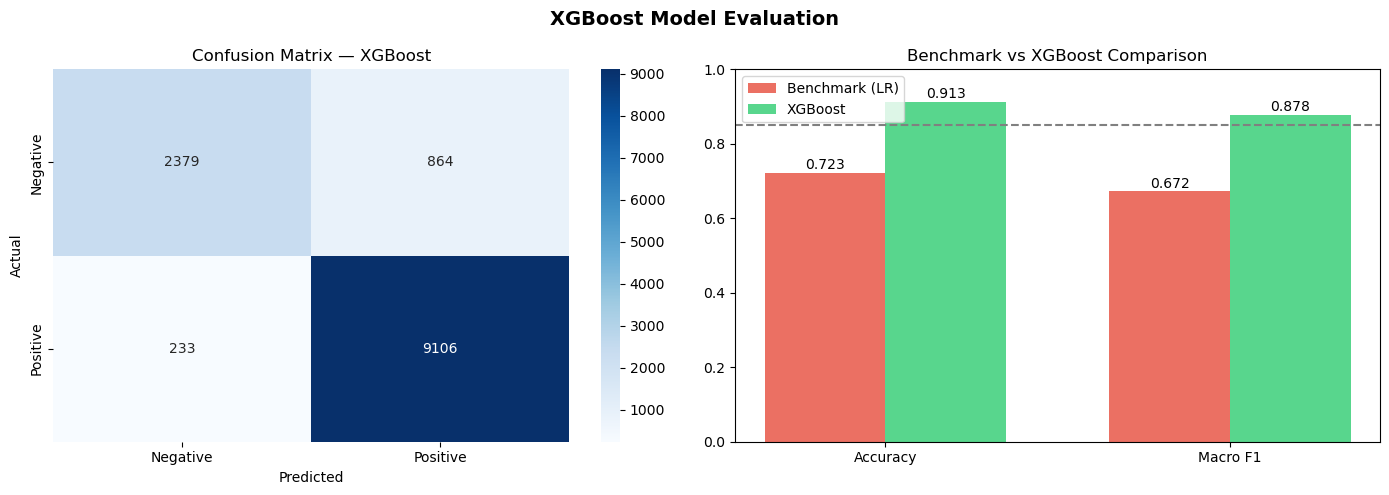


 Model improvement over benchmark:
   Accuracy: +0.1899
   Macro F1: +0.2056


In [25]:
# Classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, 
      target_names=['Negative', 'Positive']))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('XGBoost Model Evaluation', fontsize=14, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'], ax=axes[0])
axes[0].set_title('Confusion Matrix — XGBoost')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Benchmark vs XGBoost comparison bar chart
metrics = ['Accuracy', 'Macro F1']
benchmark_scores = [0.7229, 0.6723]
xgb_scores = [acc, f1]
x = np.arange(len(metrics))
width = 0.35
axes[1].bar(x - width/2, benchmark_scores, width, 
            label='Benchmark (LR)', color='#E74C3C', alpha=0.8)
axes[1].bar(x + width/2, xgb_scores, width,
            label='XGBoost', color='#2ECC71', alpha=0.8)
axes[1].set_title('Benchmark vs XGBoost Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].set_ylim(0, 1.0)
axes[1].legend()
axes[1].axhline(0.85, color='gray', linestyle='--', 
                label='Target F1=0.85')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.3f}',
                ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('xgboost_evaluation.png', bbox_inches='tight')
plt.show()

print(f"\n Model improvement over benchmark:")
print(f"   Accuracy: +{(acc - 0.7229):.4f}")
print(f"   Macro F1: +{(f1 - 0.6723):.4f}")

In [32]:
!pip install shap --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluon-timeseries 1.5.0 requires einops<1,>=0.7, which is not installed.
autogluon-timeseries 1.5.0 requires peft<0.18,>=0.13.0, which is not installed.
skops 0.14.0 requires prettytable>=3.9, which is not installed.
amazon-sagemaker-sql-magic 0.1.4 requires numpy<2, but you have numpy 2.4.6 which is incompatible.
autogluon-common 1.5.0 requires numpy<2.4.0,>=1.25.0, but you have numpy 2.4.6 which is incompatible.
autogluon-core 1.5.0 requires numpy<2.4.0,>=1.25.0, but you have numpy 2.4.6 which is incompatible.
autogluon-features 1.5.0 requires numpy<2.4.0,>=1.25.0, but you have numpy 2.4.6 which is incompatible.
autogluon-multimod

Generating ROC Curve...


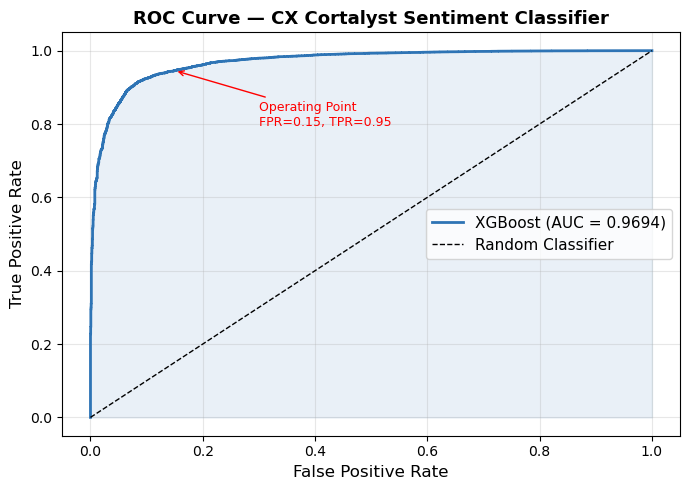

ROC curve saved.

Generating Feature Importance chart...


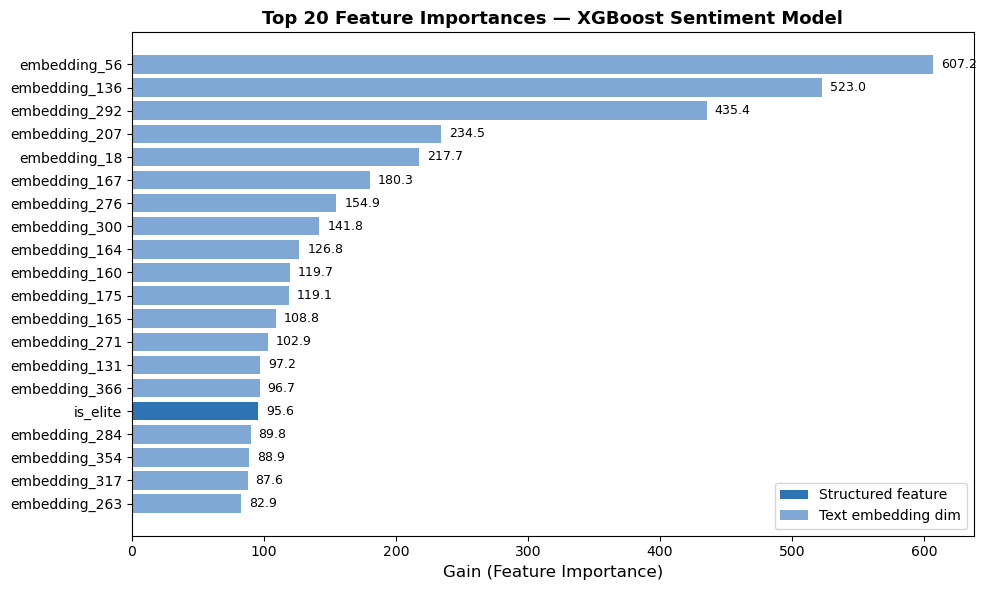

Feature importance saved.

Generating SHAP summary plot (500 row sample)...


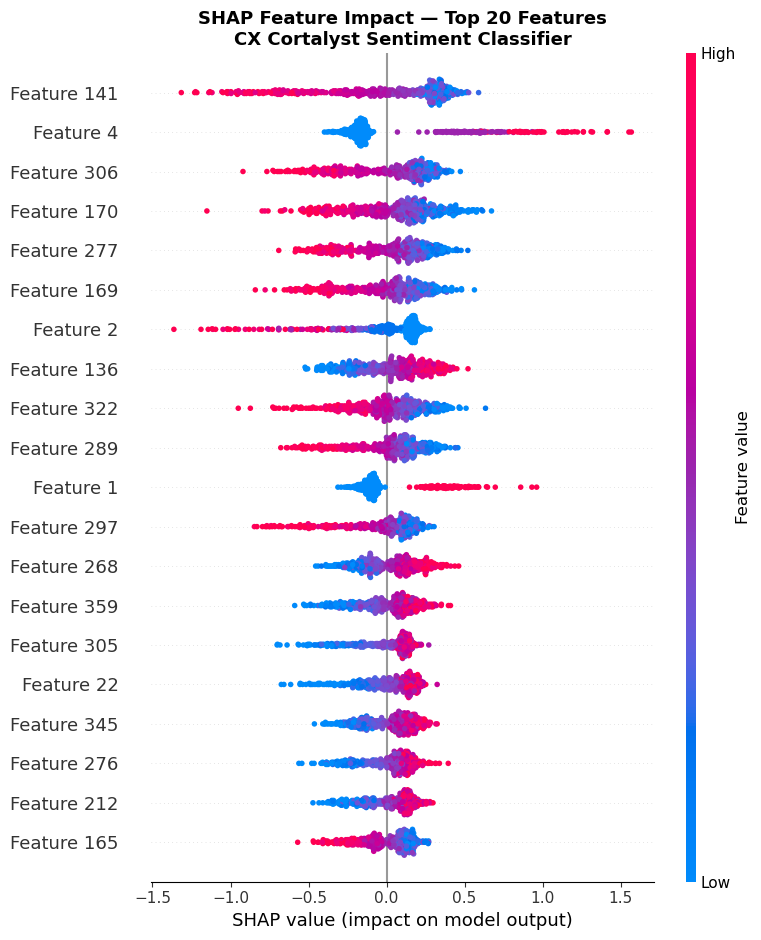

 SHAP summary saved.

╔══════════════════════════════════════════════════════╗
║      CX CORTALYST — MODEL EVALUATION SUMMARY        ║
╠══════════════════════════════════════════════════════╣
║  Model:        XGBoost (389 features)               ║
║  Embeddings:   all-MiniLM-L6-v2 (384 dims)          ║
║                                                      ║
║  TEST SET RESULTS                                    ║
║  Accuracy:     0.9128  (benchmark: 0.7229)          ║
║  Macro F1:     0.8779  (benchmark: 0.6723)          ║
║  AUC-ROC:      0.9694                               ║
║                                                      ║
║  IMPROVEMENT OVER BENCHMARK                          ║
║  Accuracy:     +0.1899                            ║
║  Macro F1:     +0.2056                            ║
║                                                      ║
║  Artifacts saved to models/                          ║
║  → roc_curve.png                                     ║
║  → feature_importan

In [27]:
import shap
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import numpy as np

# ── Create output directory ──────────────────────────────────
import os
os.makedirs('models', exist_ok=True)

# 1. ROC Curve
print("Generating ROC Curve...")

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#2E74B5', linewidth=2,
         label=f'XGBoost (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='#2E74B5')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — CX Cortalyst Sentiment Classifier', 
          fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
# Annotate the operating point at 0.5 threshold
op_idx = np.argmin(np.abs(fpr - (1 - 0.85)))
plt.annotate(f'Operating Point\nFPR={fpr[op_idx]:.2f}, TPR={tpr[op_idx]:.2f}',
             xy=(fpr[op_idx], tpr[op_idx]),
             xytext=(fpr[op_idx]+0.15, tpr[op_idx]-0.15),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=9, color='red')
plt.tight_layout()
plt.savefig('models/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("ROC curve saved.")


# 2. Feature Importance (Top 20)

print("\nGenerating Feature Importance chart...")

scores = booster.get_score(importance_type='gain')
top20  = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:20]
names, vals = zip(*top20)

# Clean up embedding feature names for display
def clean_name(n):
    if n.startswith('f') and n[1:].isdigit():
        idx = int(n[1:])
        if idx < 5:
            structured = ['text_char_length','is_elite',
                         'review_useful_votes','review_funny_votes',
                         'review_cool_votes']
            return structured[idx] if idx < len(structured) else n
        return f'embedding_{idx - 5}'
    return n

clean_names = [clean_name(n) for n in names]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2E74B5' if 'embedding' not in n else '#7FA8D4' 
          for n in clean_names]
bars = ax.barh(clean_names[::-1], vals[::-1], color=colors[::-1])
ax.set_xlabel('Gain (Feature Importance)', fontsize=12)
ax.set_title('Top 20 Feature Importances — XGBoost Sentiment Model',
             fontsize=13, fontweight='bold')

# Add value labels
for bar, val in zip(bars, vals[::-1]):
    ax.text(bar.get_width() + max(vals)*0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2E74B5', label='Structured feature'),
                   Patch(facecolor='#7FA8D4', label='Text embedding dim')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('models/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance saved.")

# 3. SHAP Summary Plot
print("\nGenerating SHAP summary plot (500 row sample)...")

# Convert test data to DMatrix-compatible numpy
X_test_sample = X_test[:500]

explainer   = shap.TreeExplainer(booster)
shap_values = explainer.shap_values(X_test_sample)

# Summary plot — beeswarm
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_test_sample,
    max_display=20,
    show=False
)
plt.title('SHAP Feature Impact — Top 20 Features\n'
          'CX Cortalyst Sentiment Classifier',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('models/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(" SHAP summary saved.")

# 4. Final Summary Print

print(f"""
╔══════════════════════════════════════════════════════╗
║      CX CORTALYST — MODEL EVALUATION SUMMARY        ║
╠══════════════════════════════════════════════════════╣
║  Model:        XGBoost (389 features)               ║
║  Embeddings:   all-MiniLM-L6-v2 (384 dims)          ║
║                                                      ║
║  TEST SET RESULTS                                    ║
║  Accuracy:     {acc:.4f}  (benchmark: 0.7229)          ║
║  Macro F1:     {f1:.4f}  (benchmark: 0.6723)          ║
║  AUC-ROC:      {auc:.4f}                               ║
║                                                      ║
║  IMPROVEMENT OVER BENCHMARK                          ║
║  Accuracy:     +{acc-0.7229:.4f}                            ║
║  Macro F1:     +{f1-0.6723:.4f}                            ║
║                                                      ║
║  Artifacts saved to models/                          ║
║  → roc_curve.png                                     ║
║  → feature_importance.png                            ║
║  → shap_summary.png                                  ║
╚══════════════════════════════════════════════════════╝
""")

In [28]:
import boto3
import json

print("--- Registering Model in SageMaker Model Registry ---")

sm_client = boto3.client('sagemaker', region_name='us-east-1')
model_package_group_name = "cx-cortalyst-sentiment-models"

# ── All metrics come from variables already computed above ───
# acc, f1, auc   → from evaluation cell
# y_test         → from test split
# xgb_estimator  → from training job
# container      → from image URI cell
# bucket         → from config cell

benchmark_acc = float(accuracy_score(y_bench_test, benchmark_model.predict(X_bench_test)))
benchmark_f1  = float(f1_score(y_bench_test, benchmark_model.predict(X_bench_test), average='macro'))

print(f"Live metrics being registered:")
print(f"  XGBoost  → Accuracy: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
print(f"  Benchmark → Accuracy: {benchmark_acc:.4f} | F1: {benchmark_f1:.4f}")


--- Registering Model in SageMaker Model Registry ---
Live metrics being registered:
  XGBoost  → Accuracy: 0.9128 | F1: 0.8779 | AUC: 0.9694
  Benchmark → Accuracy: 0.7229 | F1: 0.6723


## Create Model Package Group & Register

In [29]:
# 1. Create Model Package Group ──────────────────────
try:
    sm_client.create_model_package_group(
        ModelPackageGroupName=model_package_group_name,
        ModelPackageGroupDescription=(
            "CX Cortalyst — Sentiment Analysis XGBoost Models. "
            "Binary classifier trained on Yelp reviews using "
            "all-MiniLM-L6-v2 embeddings + structured features."
        )
    )
    print(f" Created Model Package Group: {model_package_group_name}")
except sm_client.exceptions.ClientError as e:
    if "already exists" in str(e).lower():
        print(f" Model Package Group already exists. Proceeding.")
    else:
        raise e

# 2. Build evaluation report dynamically ─────────────
evaluation_report = {
    "binary_classification_metrics": {
        "accuracy": {"value": float(acc)},
        "f1_macro": {"value": float(f1)},
        "auc_roc":  {"value": float(auc)},
    },
    "benchmark_comparison": {
        "benchmark_model":    "LogisticRegression(class_weight=balanced)",
        "benchmark_accuracy": benchmark_acc,
        "benchmark_f1":       benchmark_f1,
        "accuracy_delta":     float(round(acc - benchmark_acc, 4)),
        "f1_delta":           float(round(f1  - benchmark_f1,  4))
    },
    "training_config": {
        "algorithm":        "XGBoost 1.7",
        "num_features":     int(train_xgb.shape[1] - 1),  # minus label col
        "embedding_model":  "all-MiniLM-L6-v2",
        "train_rows":       len(train_xgb),
        "val_rows":         len(val_xgb),
        "test_rows":        len(test_xgb),
        "model_artifact":   xgb_estimator.model_data
    }
}

# 3. Save evaluation report to S3 ────────────────────
eval_s3_key = "models/evaluation/evaluation.json"
boto3.client('s3', region_name='us-east-1').put_object(
    Bucket=bucket,
    Key=eval_s3_key,
    Body=json.dumps(evaluation_report, indent=2)
)
print(f"Evaluation report → s3://{bucket}/{eval_s3_key}")

#4. Register model — all values from live variables ──
response = sm_client.create_model_package(
    ModelPackageGroupName=model_package_group_name,
    ModelPackageDescription=(
        f"XGBoost Sentiment | "
        f"Acc:{acc:.4f} F1:{f1:.4f} AUC:{auc:.4f} | "
        f"vs Benchmark Acc:{benchmark_acc:.4f} F1:{benchmark_f1:.4f}"
    ),
    InferenceSpecification={
        "Containers": [{
            "Image":        container,
            "ModelDataUrl": xgb_estimator.model_data,
        }],
        "SupportedContentTypes":      ["text/csv"],
        "SupportedResponseMIMETypes": ["text/csv"],
    },
    ModelApprovalStatus="Approved",
    CustomerMetadataProperties={
        "accuracy":         str(round(acc,           4)),
        "macro_f1":         str(round(f1,            4)),
        "auc_roc":          str(round(auc,           4)),
        "benchmark_acc":    str(round(benchmark_acc, 4)),
        "benchmark_f1":     str(round(benchmark_f1,  4)),
        "acc_delta":        str(round(acc - benchmark_acc, 4)),
        "f1_delta":         str(round(f1  - benchmark_f1,  4)),
        "num_features":     str(int(train_xgb.shape[1] - 1)),
        "train_rows":       str(len(train_xgb)),
        "embedding_model":  "all-MiniLM-L6-v2",
        "approved_by":      "Jagadeesh Kumar Sellappan"
    }
)

model_package_arn = response['ModelPackageArn']

# 5. Verify ───────────────────────────────────────────
packages = sm_client.list_model_packages(
    ModelPackageGroupName=model_package_group_name,
    SortBy='CreationTime',
    SortOrder='Descending'
)

print(f"""
Model registered successfully!
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Group:     {model_package_group_name}
  ARN:       {model_package_arn}
  Status:    Approved
  Accuracy:  {acc:.4f}  (Δ +{acc - benchmark_acc:.4f} vs benchmark)
  Macro F1:  {f1:.4f}  (Δ +{f1  - benchmark_f1:.4f} vs benchmark)
  AUC-ROC:   {auc:.4f}
  Features:  {int(train_xgb.shape[1] - 1)}
  Train rows:{len(train_xgb):,}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Model Registry — All Versions:
""")

for pkg in packages['ModelPackageSummaryList']:
    print(f"  v{pkg['ModelPackageVersion']} | "
          f"{pkg['ModelApprovalStatus']} | "
          f"{pkg['CreationTime'].strftime('%Y-%m-%d %H:%M')}")

 Model Package Group already exists. Proceeding.
Evaluation report → s3://aai-540-group8-yelp-data-301798465569-us-east-1-an/models/evaluation/evaluation.json



Model registered successfully!
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Group:     cx-cortalyst-sentiment-models
  ARN:       arn:aws:sagemaker:us-east-1:301798465569:model-package/cx-cortalyst-sentiment-models/6
  Status:    Approved
  Accuracy:  0.9128  (Δ +0.1900 vs benchmark)
  Macro F1:  0.8779  (Δ +0.2056 vs benchmark)
  AUC-ROC:   0.9694
  Features:  389
  Train rows:50,327
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Model Registry — All Versions:

  v6 | Approved | 2026-06-21 11:09
  v5 | Approved | 2026-06-15 16:36
  v4 | Approved | 2026-06-15 16:07
  v3 | Approved | 2026-06-14 12:27
  v2 | Approved | 2026-06-14 12:26
  v1 | Approved | 2026-06-14 12:04


In [31]:
!pip install awswrangler --quiet

## BATCH TRANSFORM

In [34]:
import time
import sagemaker
import awswrangler as wr
from sklearn.metrics import f1_score, accuracy_score, classification_report

# 1. Create Model ─────────────────────────────────────
model_name = f"cx-cortalyst-sentiment-{int(time.time())}"
sm_client.create_model(
    ModelName=model_name,
    PrimaryContainer={
        "Image":        container,
        "ModelDataUrl": xgb_estimator.model_data,
    },
    ExecutionRoleArn=role
)
print(f"Step 1: Model created: {model_name}")

# 2. Load + Sample Production Data ───────────────────
df_prod = wr.s3.read_parquet(
    path=f"s3://{bucket}/data/splits/production/production.parquet"
)
print(f"Step 2: Loaded {len(df_prod):,} rows from S3")

# Stratified sample — 2500 per class = 5000 total
df_prod = df_prod.groupby('sentiment_label', group_keys=False)\
                 .apply(lambda x: x.sample(min(2500, len(x)), random_state=42))
df_prod = df_prod.reset_index(drop=True)
y_prod_true = df_prod['sentiment_label'].values
print(f"   Sampled: {len(df_prod):,} rows | "
      f"Neg: {(df_prod['sentiment_label']==0).sum():,} | "
      f"Pos: {(df_prod['sentiment_label']==1).sum():,}")

# 3. Generate Embeddings ──────────────────────────────
print("Step 3: Generating embeddings...")
prod_embeddings = embedder.encode(
    df_prod['text'].tolist(),
    show_progress_bar=True,
    batch_size=64
)
print(f"   Embeddings: {prod_embeddings.shape}")

INFO:awswrangler.distributed.ray._core:Initializing a Ray instance


Step 1: Model created: cx-cortalyst-sentiment-1782040363


2026-06-21 11:12:45,759	WARNING services.py:2137 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 1938784256 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=3.35gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.


2026-06-21 11:12:45,996	INFO worker.py:2007 -- Started a local Ray instance.


/opt/conda/lib/python3.12/site-packages/ray/_private/worker.py:2046: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


Step 2: Loaded 50,328 rows from S3
   Sampled: 5,000 rows | Neg: 2,500 | Pos: 2,500
Step 3: Generating embeddings...


/tmp/ipykernel_7104/3025480648.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(2500, len(x)), random_state=42))


Batches:   0%|          | 0/79 [00:00<?, ?it/s]

   Embeddings: (5000, 384)


In [35]:
# 4. Build Feature Matrix ─────────────────────────────
numerical_cols = [
    'text_char_length',
    'is_elite',
    'review_useful_votes',
    'review_funny_votes',
    'review_cool_votes'
]

# No index= argument — use default 0-based index throughout
df_prod_embeddings = pd.DataFrame(prod_embeddings)

X_prod = pd.concat([
    df_prod[numerical_cols].fillna(0).reset_index(drop=True),
    df_prod_embeddings
], axis=1)

print(f"Step 4: Feature matrix: {X_prod.shape}")

# 5. Save + Upload to S3 ──────────────────────────────
prod_csv_path  = 'prod_inference.csv'
s3_prod_input  = f"s3://{bucket}/data/sagemaker_input/production/"
s3_prod_output = f"s3://{bucket}/data/batch_output/production/"

X_prod.to_csv(prod_csv_path, header=False, index=False)
sagemaker_session.upload_data(
    prod_csv_path,
    bucket=bucket,
    key_prefix='data/sagemaker_input/production'
)
print(f"Step 5: Uploaded to {s3_prod_input}")

Step 4: Feature matrix: (5000, 389)


Step 5: Uploaded to s3://aai-540-group8-yelp-data-301798465569-us-east-1-an/data/sagemaker_input/production/


In [36]:
# 6. Run Batch Transform Job ──────────────────────────
transform_job_name = f"cx-cortalyst-batch-{int(time.time())}"

transformer = sagemaker.transformer.Transformer(
    model_name=model_name,
    instance_count=1,
    instance_type='ml.m5.xlarge',
    output_path=s3_prod_output,
    base_transform_job_name=transform_job_name,
    sagemaker_session=sagemaker_session,
    accept='text/csv',
    assemble_with='Line',
    strategy='MultiRecord'
)

print(f"\n Step 6: Starting Batch Transform Job...")
print(f"   Input:  {s3_prod_input}")
print(f"   Output: {s3_prod_output}")

transformer.transform(
    data=s3_prod_input,
    content_type='text/csv',
    split_type='Line',
    wait=True,
    logs=True
)
print(" Batch Transform completed!")


INFO:sagemaker:Creating transform job with name: cx-cortalyst-batch-1782040677-2026-06-21-11-17-57-753



 Step 6: Starting Batch Transform Job...
   Input:  s3://aai-540-group8-yelp-data-301798465569-us-east-1-an/data/sagemaker_input/production/
   Output: s3://aai-540-group8-yelp-data-301798465569-us-east-1-an/data/batch_output/production/


.

.

.

...

.

.

/miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-06-21:11:22:48:INFO] No GPUs detected (normal if no gpus installed)
[2026-06-21:11:22:48:INFO] No GPUs detected (normal if no gpus installed)
[2026-06-21:11:22:48:INFO] nginx config: 
worker_processes auto;
daemon off;
pid /tmp/nginx.pid;
error_log  /dev/stderr;
worker_rlimit_nofile 4096;
events {
  worker_connections 2048;
}
http {
  include /etc/nginx/mime.types;
  default_type application/octet-stream;
  access_log /dev/stdout combined;
  upstream gunicorn {
    server unix:/tmp/gunicorn.sock;
  }
  server {
    listen 8080 deferred;
    client_max_body_size 0;
    keepalive_timeout 3;
    location ~ ^/(ping|invocations|execution-parameters) 

[2026-06-21:11:22:54:INFO] No GPUs detected (normal if no gpus installed)
[2026-06-21:11:22:54:INFO] Determined delimiter of CSV input is ','
[2026-06-21:11:22:54:INFO] No GPUs detected (normal if no gpus installed)
[2026-06-21:11:22:54:INFO] Determined delimiter of CSV input is ','
[2026-06-21:11:22:54:INFO] Determined delimiter of CSV input is ','
[2026-06-21:11:22:54:INFO] No GPUs detected (normal if no gpus installed)
[2026-06-21:11:22:55:INFO] Determined delimiter of CSV input is ','
[2026-06-21:11:22:54:INFO] No GPUs detected (normal if no gpus installed)
[2026-06-21:11:22:54:INFO] Determined delimiter of CSV input is ','
[2026-06-21:11:22:54:INFO] No GPUs detected (normal if no gpus installed)
[2026-06-21:11:22:54:INFO] Determined delimiter of CSV input is ','
[2026-06-21:11:22:54:INFO] Determined delimiter of CSV input is ','
[2026-06-21:11:22:54:INFO] No GPUs detected (normal if no gpus installed)
[2026-06-21:11:22:55:INFO] Determined delimiter of CSV input is ','
2026-06-21T1

 Batch Transform completed!


In [39]:
# 7. Read + Evaluate Predictions ──────────────────────
print("\n Step 7: Reading predictions from S3...")

df_predictions = wr.s3.read_csv(path=s3_prod_output, header=None)
df_predictions.columns = ['predicted_proba']
df_predictions['predicted_label'] = (
    df_predictions['predicted_proba'] >= 0.5
).astype(int)
df_predictions['review_id'] = df_prod['review_id'].values
df_predictions['true_label'] = y_prod_true

prod_acc = accuracy_score(y_prod_true, df_predictions['predicted_label'])
prod_f1  = f1_score(y_prod_true, df_predictions['predicted_label'],
                    average='macro')

print(f"""
╔══════════════════════════════════════════════════════╗
║      BATCH TRANSFORM — PRODUCTION RESULTS            ║
╠══════════════════════════════════════════════════════╣
║  Records processed:  {len(df_predictions):,}         ║
║  Accuracy:           {prod_acc:.4f}                  ║
║  Macro F1:           {prod_f1:.4f}                   ║
║  Test set F1:        {f1:.4f}  ← should be similar   ║
║  Delta (prod-test):  {prod_f1 - f1:+.4f}             ║
╚══════════════════════════════════════════════════════╝
""")

print(classification_report(
    y_prod_true,
    df_predictions['predicted_label'], 
    target_names=['Negative', 'Positive']
))

# 8. Save Predictions to S3 ───────────────────────────
predictions_path = (f"s3://{bucket}/data/predictions/"
                    f"production_predictions.parquet")
wr.s3.to_parquet(df=df_predictions, path=predictions_path, index=False)

print(f" Step 8: Predictions saved → {predictions_path}")
print(f"\n These predictions will be used for:")
print(f"   → Model Monitor baseline")
print(f"   → Drift detection simulation")


 Step 7: Reading predictions from S3...



╔══════════════════════════════════════════════════════╗
║      BATCH TRANSFORM — PRODUCTION RESULTS            ║
╠══════════════════════════════════════════════════════╣
║  Records processed:  5,000         ║
║  Accuracy:           0.8504                  ║
║  Macro F1:           0.8477                   ║
║  Test set F1:        0.8779  ← should be similar   ║
║  Delta (prod-test):  -0.0302             ║
╚══════════════════════════════════════════════════════╝

              precision    recall  f1-score   support

    Negative       0.98      0.72      0.83      2500
    Positive       0.78      0.98      0.87      2500

    accuracy                           0.85      5000
   macro avg       0.88      0.85      0.85      5000
weighted avg       0.88      0.85      0.85      5000

 Step 8: Predictions saved → s3://aai-540-group8-yelp-data-301798465569-us-east-1-an/data/predictions/production_predictions.parquet

 These predictions will be used for:
   → Model Monitor baseline
   → D

## Run this cleanup cell now

In [40]:

import boto3

sm_client = boto3.client('sagemaker', region_name='us-east-1')

# 1. Delete Batch Transform model 
# try:
#     sm_client.delete_model(ModelName=model_name)
#     print(f"✅ Deleted model: {model_name}")
# except Exception as e:
#     print(f"ℹ️  {e}")

# 2. Check for any running endpoints 
endpoints = sm_client.list_endpoints(StatusEquals='InService')
if endpoints['Endpoints']:
    for ep in endpoints['Endpoints']:
        print(f"⚠️  Running endpoint found: {ep['EndpointName']}")
        # Uncomment to delete:
        # sm_client.delete_endpoint(EndpointName=ep['EndpointName'])
else:
    print("No running endpoints")

# 3. Check for running training jobs
jobs = sm_client.list_training_jobs(StatusEquals='InProgress')
if jobs['TrainingJobSummaries']:
    for job in jobs['TrainingJobSummaries']:
        print(f"⚠️  Running training job: {job['TrainingJobName']}")
else:
    print("No running training jobs")

print("\nCleanup complete — safe to stop instance")

No running endpoints
No running training jobs

Cleanup complete — safe to stop instance
